In [2]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Load dataset
df = pd.read_csv('/kaggle/input/YOUR_DATASET_FOLDER/YOUR_FILE.csv')

# Show first 5 rows
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/YOUR_DATASET_FOLDER/YOUR_FILE.csv'

In [4]:
import os

# Show all input files
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

/kaggle/input/datasets/arnavs19/phishing-websites-dataset/dataset_full.csv
/kaggle/input/datasets/arnavs19/phishing-websites-dataset/dataset_small.csv


In [5]:
# Load dataset
df = pd.read_csv('/kaggle/input/datasets/arnavs19/phishing-websites-dataset/dataset_full.csv')

# Show first 5 rows
df.head()

,qty_dot_url,qty_hyphen_url,qty_underline_url,qty_slash_url,qty_questionmark_url,qty_equal_url,qty_at_url,qty_and_url,qty_exclamation_url,qty_space_url,...,qty_ip_resolved,qty_nameservers,qty_mx_servers,ttl_hostname,tls_ssl_certificate,qty_redirects,url_google_index,domain_google_index,url_shortened,phishing
0,3,0,0,1,0,0,0,0,0,0,...,1,2,0,892,0,0,0,0,0,1
1,5,0,1,3,0,3,0,2,0,0,...,1,2,1,9540,1,0,0,0,0,1
2,2,0,0,1,0,0,0,0,0,0,...,1,2,3,589,1,0,0,0,0,0
3,4,0,2,5,0,0,0,0,0,0,...,1,2,0,292,1,0,0,0,0,1
4,2,0,0,0,0,0,0,0,0,0,...,1,2,1,3597,0,1,0,0,0,0


In [6]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:\n")
print(df.columns)

# Dataset info
print("\nDataset Info:\n")
print(df.info())

Dataset Shape: (88647, 112)

Columns:

Index(['qty_dot_url', 'qty_hyphen_url', 'qty_underline_url', 'qty_slash_url',
       'qty_questionmark_url', 'qty_equal_url', 'qty_at_url', 'qty_and_url',
       'qty_exclamation_url', 'qty_space_url',
       ...
       'qty_ip_resolved', 'qty_nameservers', 'qty_mx_servers', 'ttl_hostname',
       'tls_ssl_certificate', 'qty_redirects', 'url_google_index',
       'domain_google_index', 'url_shortened', 'phishing'],
      dtype='object', length=112)

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88647 entries, 0 to 88646
Columns: 112 entries, qty_dot_url to phishing
dtypes: float64(1), int64(111)
memory usage: 75.7 MB
None


In [7]:
# Missing values
print(df.isnull().sum())

qty_dot_url             0
qty_hyphen_url          0
qty_underline_url       0
qty_slash_url           0
qty_questionmark_url    0
                       ..
qty_redirects           0
url_google_index        0
domain_google_index     0
url_shortened           0
phishing                0
Length: 112, dtype: int64


In [8]:
df.head()

,qty_dot_url,qty_hyphen_url,qty_underline_url,qty_slash_url,qty_questionmark_url,qty_equal_url,qty_at_url,qty_and_url,qty_exclamation_url,qty_space_url,...,qty_ip_resolved,qty_nameservers,qty_mx_servers,ttl_hostname,tls_ssl_certificate,qty_redirects,url_google_index,domain_google_index,url_shortened,phishing
0,3,0,0,1,0,0,0,0,0,0,...,1,2,0,892,0,0,0,0,0,1
1,5,0,1,3,0,3,0,2,0,0,...,1,2,1,9540,1,0,0,0,0,1
2,2,0,0,1,0,0,0,0,0,0,...,1,2,3,589,1,0,0,0,0,0
3,4,0,2,5,0,0,0,0,0,0,...,1,2,0,292,1,0,0,0,0,1
4,2,0,0,0,0,0,0,0,0,0,...,1,2,1,3597,0,1,0,0,0,0


In [9]:
# Features (all columns except phishing)
X = df.drop('phishing', axis=1)

# Target column
y = df['phishing']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (88647, 111)
Target Shape: (88647,)


In [10]:
# Split dataset into training and testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (70917, 111)
Testing Data Shape: (17730, 111)


In [11]:
# Create Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [12]:
# Predict labels

y_pred = rf_model.predict(X_test)

# Predict probabilities
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("Predictions Completed!")

Predictions Completed!


In [13]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)

# Print results

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Accuracy : 0.9698
Precision: 0.9519
Recall   : 0.9611
F1 Score : 0.9565
ROC-AUC  : 0.9949


In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98     11612
           1       0.95      0.96      0.96      6118

    accuracy                           0.97     17730
   macro avg       0.97      0.97      0.97     17730
weighted avg       0.97      0.97      0.97     17730



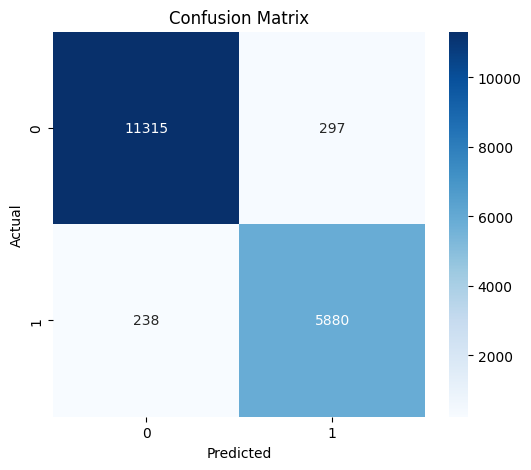

In [15]:
# Create confusion matrix

cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [16]:
# Features and Target

X = df.drop('phishing', axis=1)
y = df['phishing']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (88647, 111)
Target Shape: (88647,)


In [17]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (70917, 111)
Testing Shape: (17730, 111)


In [18]:
# Random Forest Model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [19]:
# Predictions

y_pred = rf_model.predict(X_test)

y_prob = rf_model.predict_proba(X_test)[:,1]

print("Prediction Completed!")

Prediction Completed!


In [21]:
# Evaluation Metrics

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))
print("ROC-AUC  :", round(roc_auc,4))

Accuracy : 0.9698
Precision: 0.9519
Recall   : 0.9611
F1 Score : 0.9565
ROC-AUC  : 0.9949


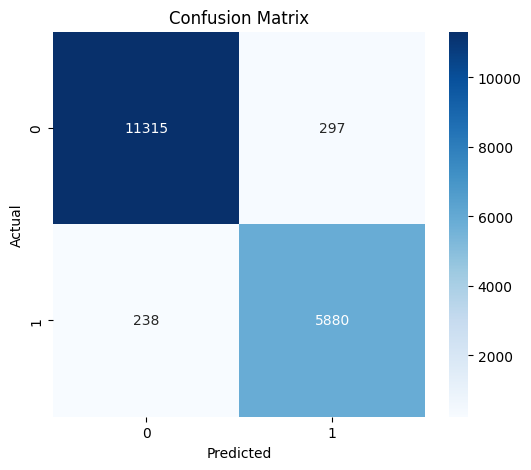

In [22]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

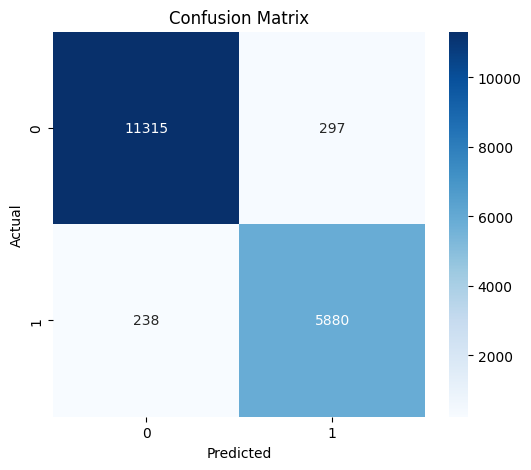

In [23]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.pdf")

plt.show()

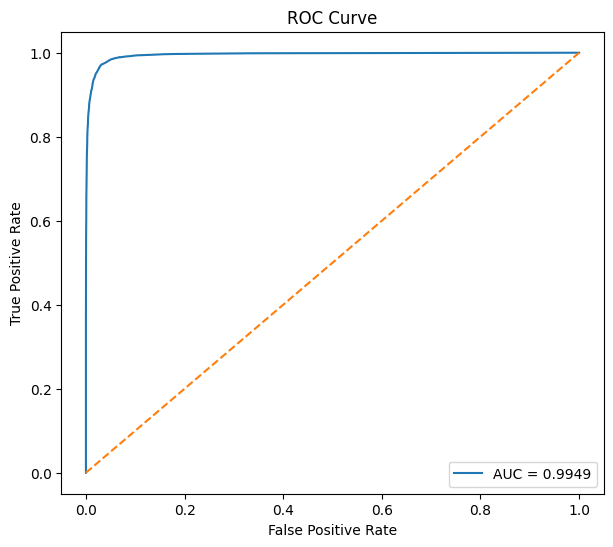

In [24]:
# ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.4f}'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()

plt.savefig("roc_curve.pdf")

plt.show()

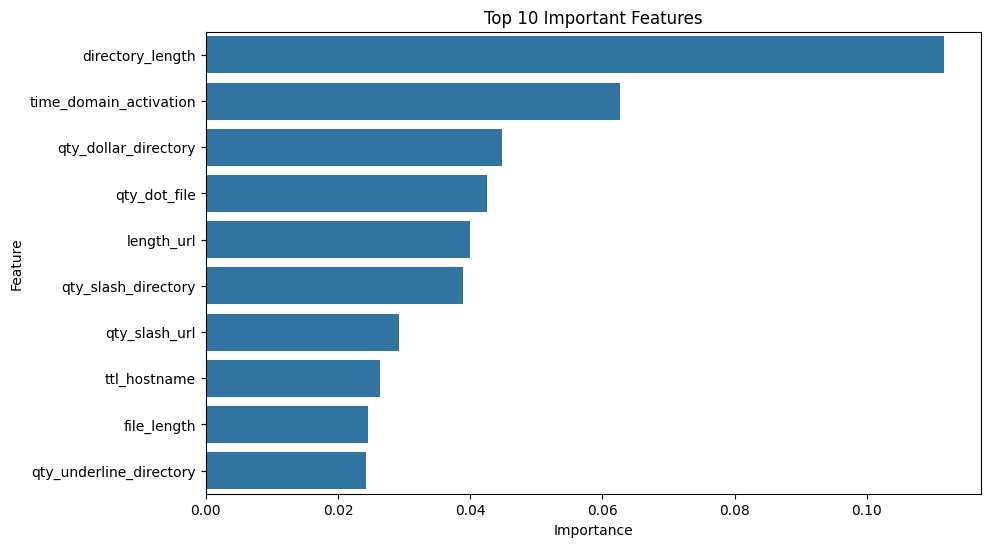

,Feature,Importance
57,directory_length,0.111673
100,time_domain_activation,0.062684
55,qty_dollar_directory,0.044789
58,qty_dot_file,0.042567
18,length_url,0.039925
43,qty_slash_directory,0.038971
3,qty_slash_url,0.029151
105,ttl_hostname,0.026319
75,file_length,0.024528
42,qty_underline_directory,0.024218


In [25]:
# Feature Importance

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top 10 Important Features")

plt.savefig("feature_importance.pdf")

plt.show()

top_features

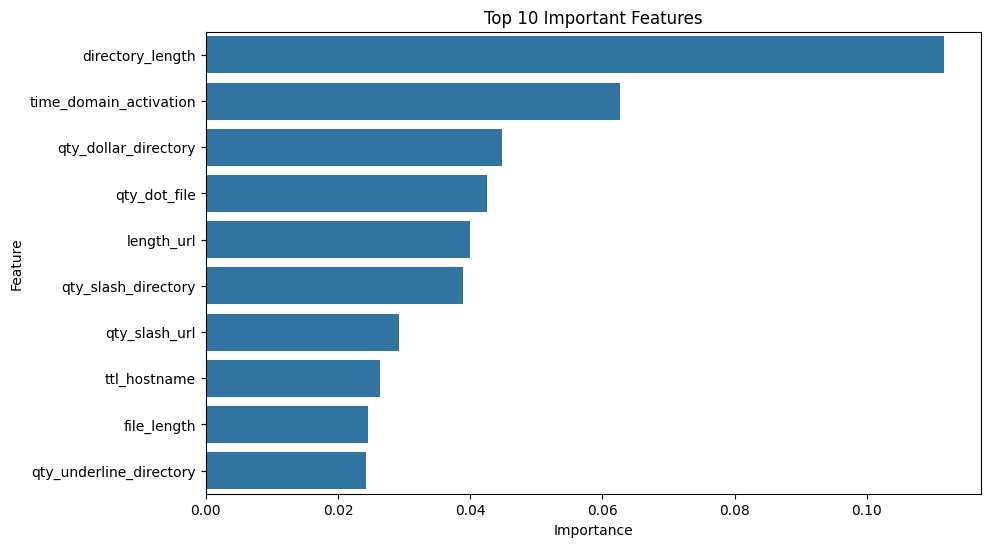

,Feature,Importance
57,directory_length,0.111673
100,time_domain_activation,0.062684
55,qty_dollar_directory,0.044789
58,qty_dot_file,0.042567
18,length_url,0.039925
43,qty_slash_directory,0.038971
3,qty_slash_url,0.029151
105,ttl_hostname,0.026319
75,file_length,0.024528
42,qty_underline_directory,0.024218


In [26]:
# Feature Importance

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top 10 Important Features")

plt.savefig("feature_importance.pdf")

plt.show()

top_features

In [28]:
# Save metrics table

results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ],
    'Value': [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results.to_csv("evaluation_metrics.csv", index=False)

results

,Metric,Value
0,Accuracy,0.969825
1,Precision,0.951918
2,Recall,0.961098
3,F1 Score,0.956486
4,ROC-AUC,0.994932
